In [1]:
using CSV
using DataFrames
using DelimitedFiles
using CairoMakie
using LsqFit

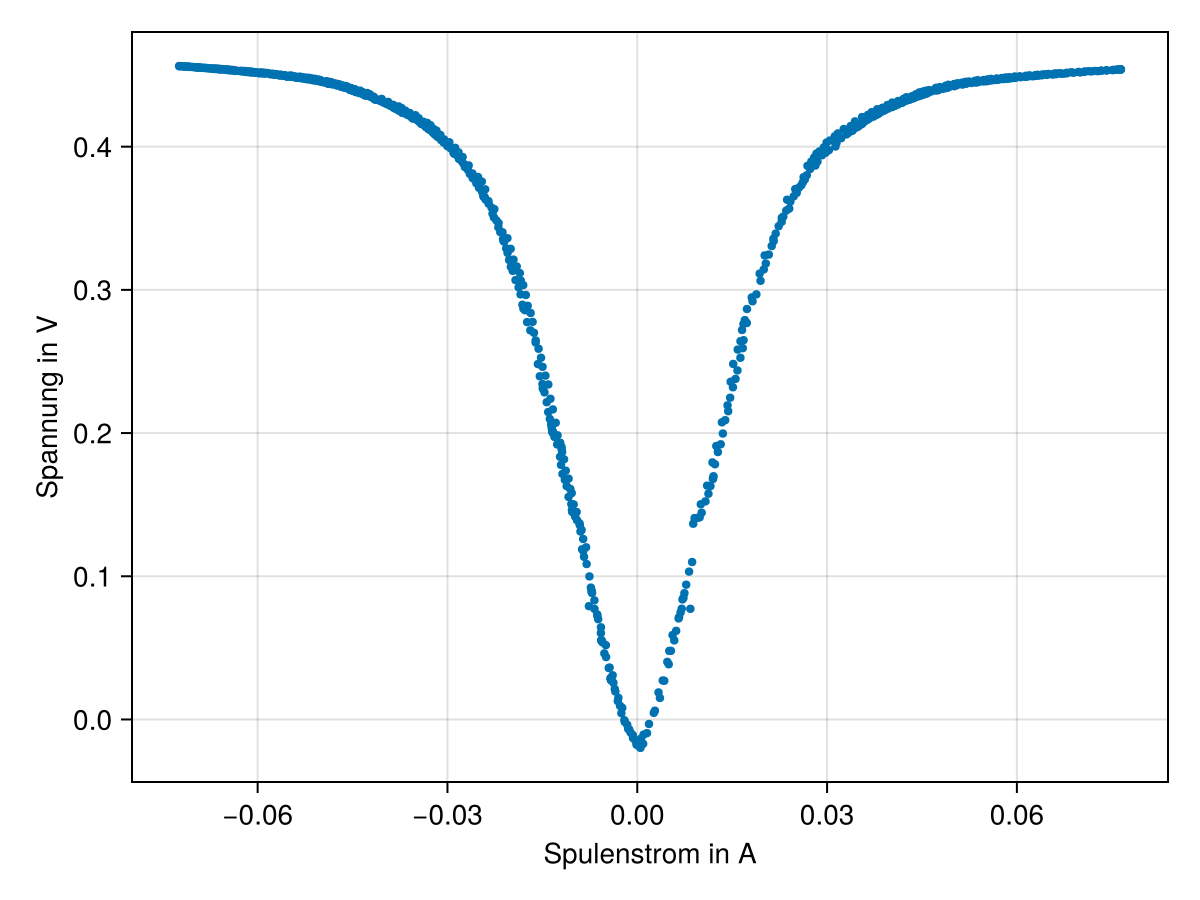

In [44]:
messung_2_2 = readdlm("sensor2_2", Float64, skipstart = 2)

I22 = messung_2_2[:,1]
U22 = messung_2_2[:,2]

fig = Figure()
ax = Axis(fig[1,1], xlabel="Spulenstrom in A", ylabel="Spannung in V", xticks = LinearTicks(6))
scatter!(ax, I22, U22, markersize=6)
fig

In [4]:
save("Spannung_Strom_Sensor_2_2.pdf",fig)

CairoMakie.Screen{PDF}


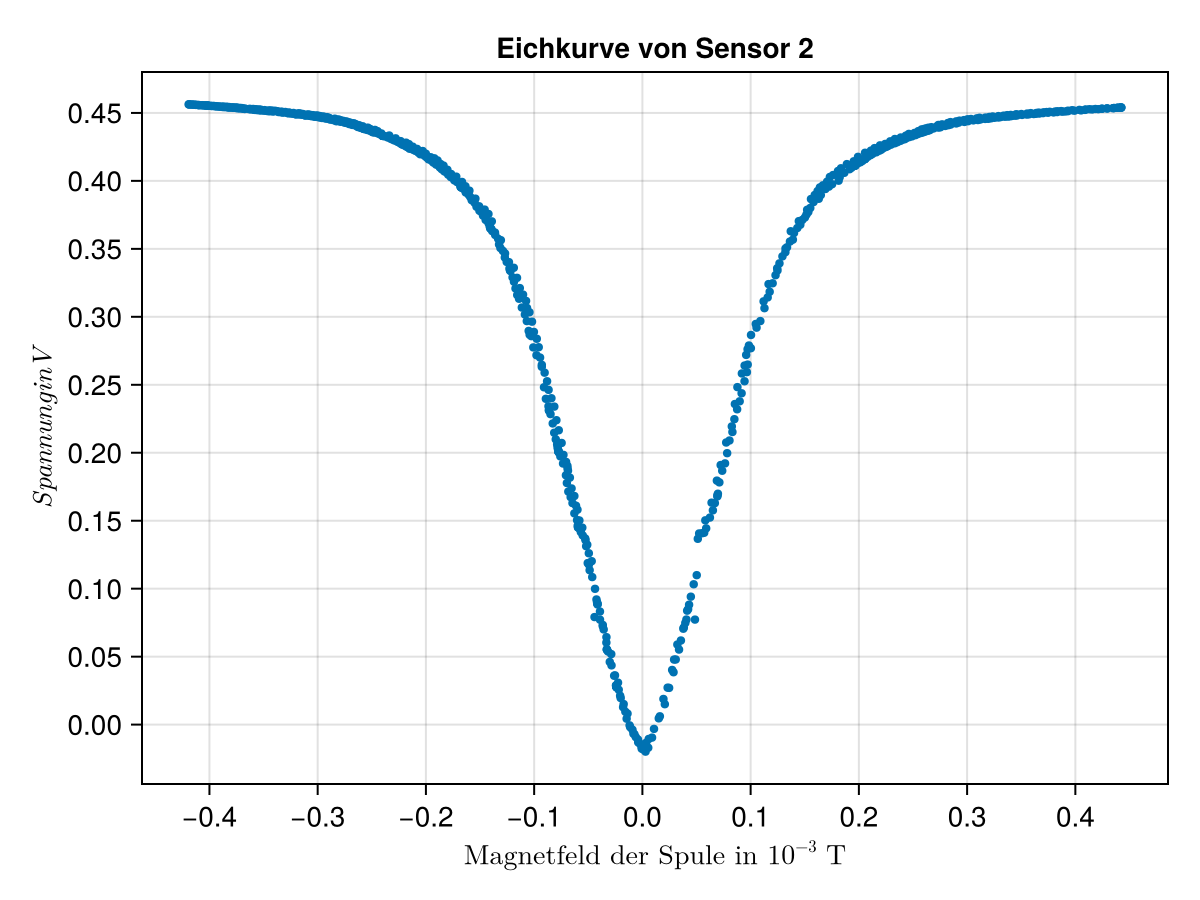

In [40]:
#B berechnen
N = 691
L = 0.15 # in m
μ0 = 4π*1e-7

B22 = I22 .* (μ0*N/L)
B22_skaliert = B22 ./ 1e-3 #Damit x-Achse nicht so voll, gröenordnung in beschritung

fig2 = Figure()
ax=Axis(fig2[1,1], xlabel= L"Magnetfeld der Spule in $10^{-3}$ T", ylabel=L"Spannung in V",
 title="Eichkurve von Sensor 2", xticks = LinearTicks(11), yticks = LinearTicks(11))
scatter!(ax, B22_skaliert, U22, markersize=6)
fig2

In [8]:
save("Eichkurve_Sensor_2.pdf", fig2)

CairoMakie.Screen{PDF}


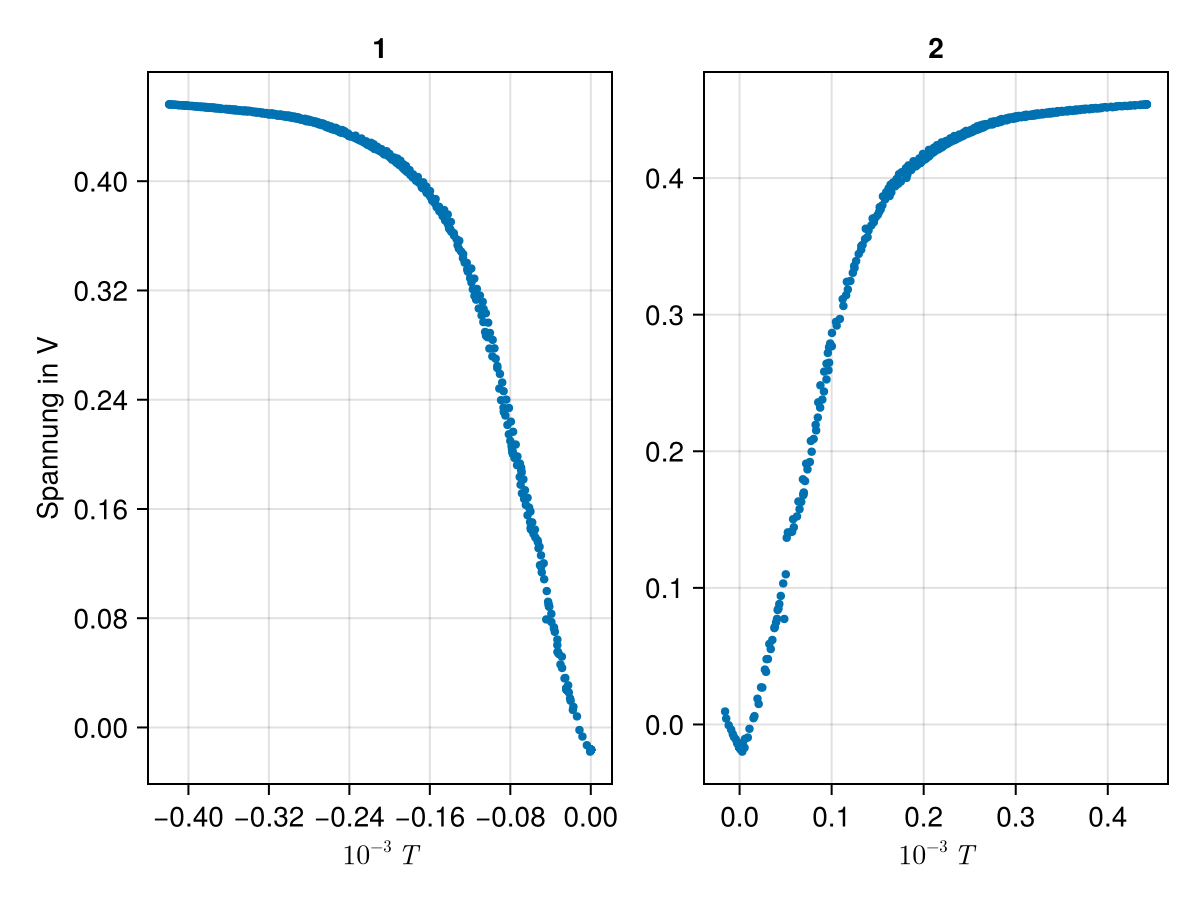

In [11]:
länge = length(B22)
H = round(Int, länge /2)
#1. Hälfte, aufsteigend
U22_1 = U22[1:H]
B22_skaliert_1 = B22_skaliert[1:H]

#2.Hälft2, absteigend
U22_2 =U22[H+1:end]
B22_skaliert_2 = B22_skaliert[H+1:end]

fig3 = Figure()
ax1 = Axis(fig3[1,1], xlabel = L" 10^{-3}\:T", ylabel ="Spannung in V", title ="1",
xticks = LinearTicks(6), yticks = LinearTicks(7))
ax2 = Axis(fig3[1,2], xlabel = L" 10^{-3}\:T", title ="2", xticks = LinearTicks(6), 
yticks = LinearTicks(6))

scatter!(ax1, B22_skaliert_1, U22_1, markersize=6)
scatter!(ax2, B22_skaliert_2, U22_2, markersize=6)
fig3

In [45]:
mask_pos = (B22_skaliert_2 .>=0.01) .& (B22_skaliert_2 .<0.12)
mask_neg = (B22_skaliert_1 .>=-0.11) .& (B22_skaliert_1 .<-0.02)

x_fit_1 = B22_skaliert_1[mask_neg]
y_fit_1 = U22_1[mask_neg]

x_fit_2 = B22_skaliert_2[mask_pos]
y_fit_2 = U22_2[mask_pos];


Steigung m = -3.313225387926789 ± 0.023004093850297936
y-Abschnitt b =-0.0482054244572536 ± 0.0015451306166181804


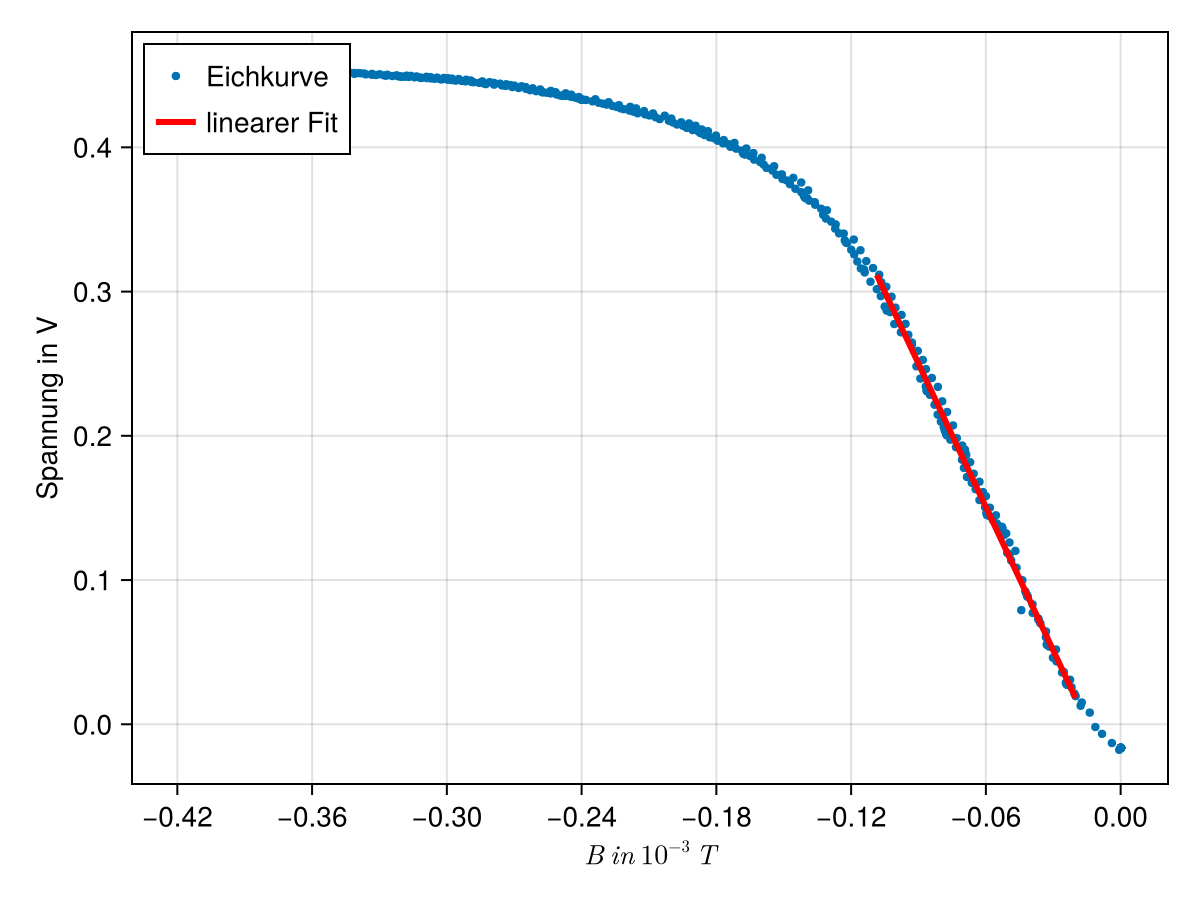

In [46]:
#fit1  durchführen 
@. gerade(x, p) = p[1]*x + p[2]
p0 = [-2.45, 0.0]
fit = curve_fit(gerade, x_fit_1, y_fit_1, p0)

#m und b geben lassen
m, b = fit.param
Δm, Δb = stderror(fit)

println("Steigung m = $m ± $Δm")
println("y-Abschnitt b =$b ± $Δb")

fig6= Figure()
ax = Axis(fig6[1,1], title = "" ,xlabel = L"B\: in\: 10^{-3}\:T ", ylabel = "Spannung in V",
xticks = LinearTicks(8))


scatter!(ax, B22_skaliert_1, U22_1, label = "Eichkurve", markersize = 6)


T_fit = range(minimum(x_fit_1 ), maximum(x_fit_1), length = 200)
y_fit = gerade(T_fit, fit.param)

lines!(ax, T_fit, y_fit, label = "linearer Fit", color = :red, linewidth = 3)

axislegend(ax, position = :lt)

fig6

Steigung m = 3.2244906835530367 ± 0.031320158471649526
y-Abschnitt b =-0.048153078899359235 ± 0.002270121254043503


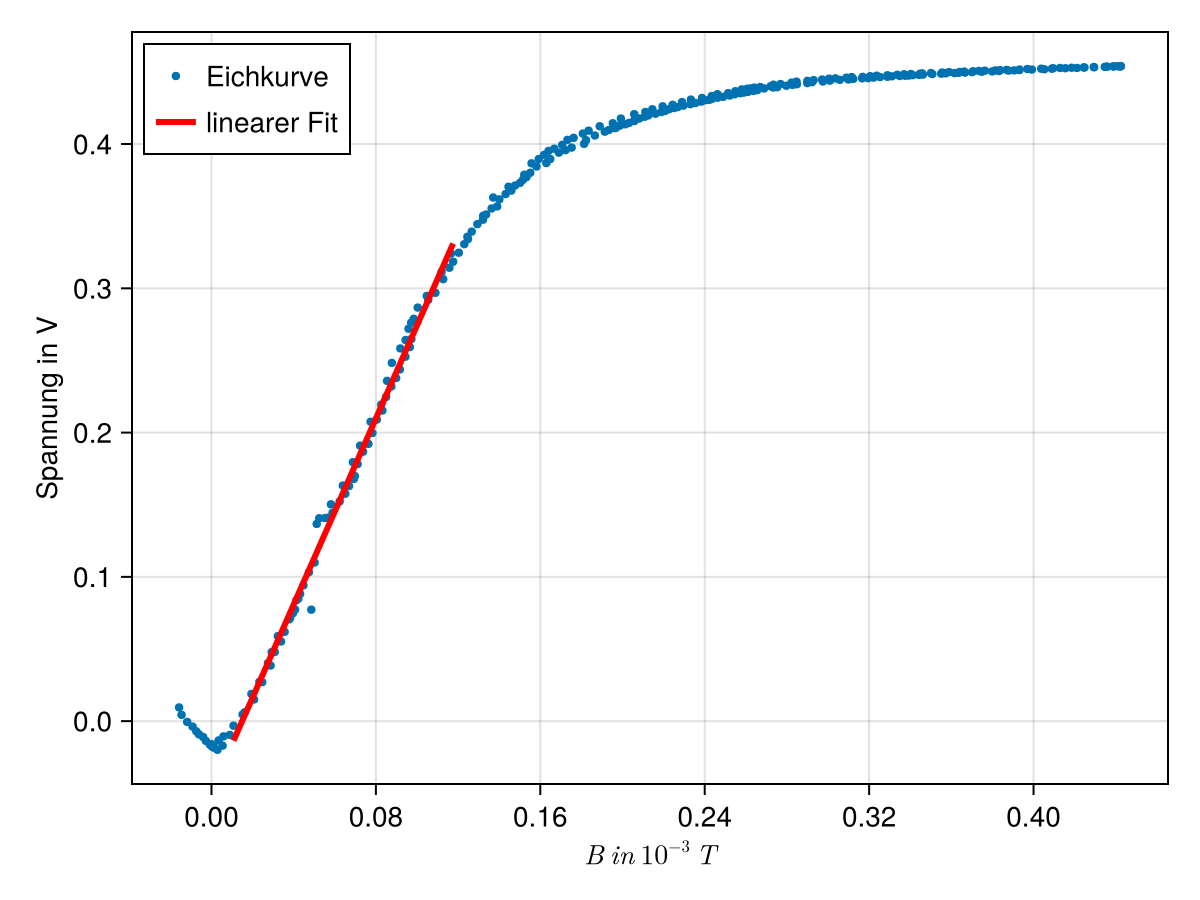

In [37]:
#fit2
@. gerade(x, p) = p[1]*x + p[2]
p0 = [2.27, 0.027]
fit = curve_fit(gerade, x_fit_2, y_fit_2, p0)

#m und b geben lassen
m, b = fit.param
Δm, Δb = stderror(fit)

println("Steigung m = $m ± $Δm")
println("y-Abschnitt b =$b ± $Δb")

fig7= Figure()
ax = Axis(fig7[1,1], title = "" ,xlabel = L"B\: in\: 10^{-3}\:T ", ylabel = "Spannung in V",
xticks = LinearTicks(8))


scatter!(ax, B22_skaliert_2, U22_2, label = "Eichkurve", markersize = 6)


T_fit = range(minimum(x_fit_2 ), maximum(x_fit_2), length = 100)
y_fit = gerade(T_fit, fit.param)

lines!(ax, T_fit, y_fit, label = "linearer Fit", color = :red, linewidth = 3)

axislegend(ax, position = :lt)

fig7



In [38]:
save("Fit_neg_Sensor_2.pdf",fig6)
save("Fit_pos_Sensor_2.pdf",fig7)

CairoMakie.Screen{PDF}
